# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

c:\Users\Kazem\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Kazem\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Kazem\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

### Importing the dataset

In [2]:
dataset = pd.read_csv("./../../../data/raw/Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [3]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [5]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

A feedforward neural network is constructed with:

*   Two hidden layers (both 6 neurons) using ReLU activation function.
*   One output layer with Sigmoid activation function for binary classification.

ReLU is used to introduce non-linearity, while Sigmoid outputs probabilities between 0 and 1.

### Initializing the ANN

In [8]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

### Adding the second hidden layer

In [10]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [11]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

### Handling Class Imbalance

In this step, we address the class imbalance problem by applying **class weights** technique:

We calculate class weights to give higher importance to the minority class (churn), ensuring the model doesn't ignore churn customers.

it will help improve recall for the churn class.


In [12]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights: ", class_weight_dict)

Class Weights:  {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN
The model is compiled using:


*   **Adam optimizer** with learning rate 0.001 for efficient gradient updates.
*   **Binary Crossentropy loss**, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.








In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint
**ModelCheckpoint** saves the best-performing model during training.
These techniques improve model generalization and reproducibility.

In [14]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Training the ANN on the Training set

The model is trained for up to 100 epochs with a batch size of 32.
A validation split is used to monitor generalization performance during training.

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,  # Using class weights
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4925 - auc: 0.4474 - loss: 0.7534 - precision: 0.1764 - recall: 0.4031 - val_accuracy: 0.4544 - val_auc: 0.5370 - val_loss: 0.6890 - val_precision: 0.2055 - val_recall: 0.6031
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5123 - auc: 0.5977 - loss: 0.6759 - precision: 0.2390 - recall: 0.6328 - val_accuracy: 0.5713 - val_auc: 0.6469 - val_loss: 0.6582 - val_precision: 0.2654 - val_recall: 0.6469
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6208 - auc: 0.6817 - loss: 0.6414 - precision: 0.2993 - recall: 0.6359 - val_accuracy: 0.6400 - val_auc: 0.6979 - val_loss: 0.6271 - val_precision: 0.3134 - val_recall: 0.6719
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6652 - auc: 0.7172 - loss: 0.6180 - precision: 0.3361 - recall: 0.6519 - val_accuracy: 0.6450 - val_auc: 0.7260 - val_loss: 0.6169 - val_precision: 0.3218 - val_recall: 0.7000
Epoch 5/100
200/200 ━━━━━━━━

### Performance Visualization - Training and Validation Curves

Loss and performance metrics are plotted over epochs.
These curves help diagnose:

*   Underfitting
*   Overfitting
*   Training stability

Visualization allows better understanding of model learning behavior.

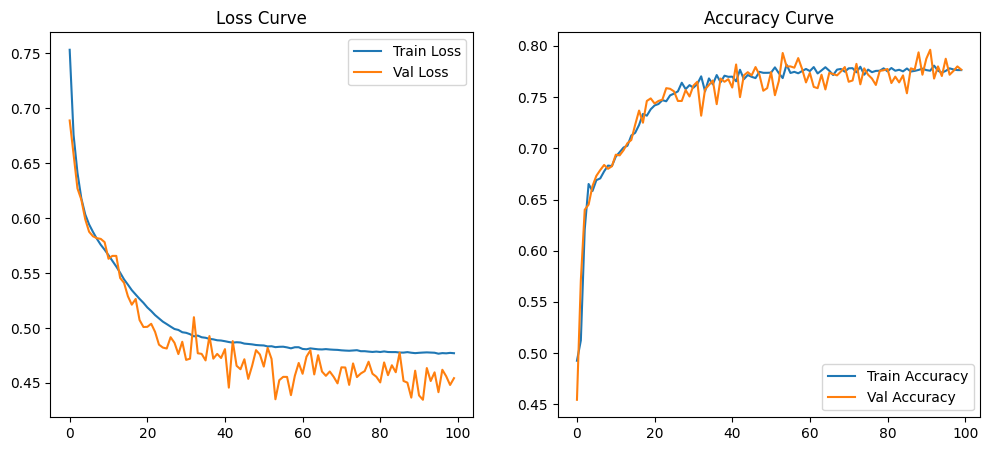

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

## **Predicting and evaluating the model**

The trained model is evaluated on the test set.

### Confusion Matrix Analysis

The confusion matrix provides detailed insight into classification errors:

*   True Positives (TP)
*   True Negatives (TN)
*   False Positives (FP)
*   False Negatives (FN)

This analysis is critical in churn prediction, where missing churned customers (FN) may be costly.

In [17]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step

Confusion Matrix:
 [[1231  362]
 [ 101  306]]


**Performance metrics** such as Accuracy, Precision, Recall, F1-score, and AUC are calculated to assess generalization ability.

In [18]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.4693498909473419, 0.7684999704360962, 0.458083838224411, 0.751842737197876, 0.8516976237297058]

Classification Report:

              precision    recall  f1-score   support

           0     0.9242    0.7728    0.8417      1593
           1     0.4581    0.7518    0.5693       407

    accuracy                         0.7685      2000
   macro avg     0.6911    0.7623    0.7055      2000
weighted avg     0.8293    0.7685    0.7863      2000

ROC-AUC: 0.8516204956882922


### Plotting ROC Curve

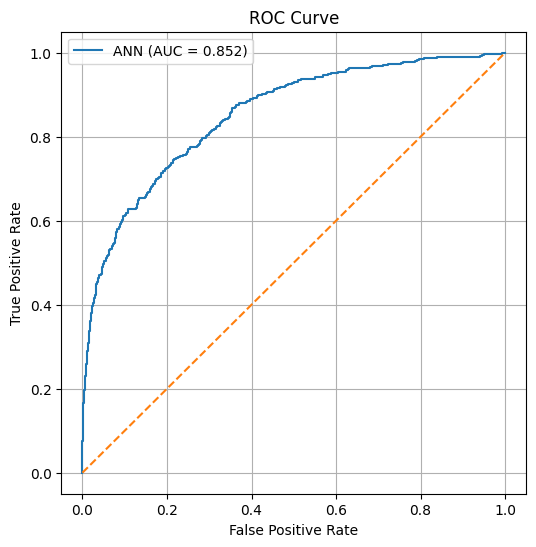

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Impact of Applying Class Weights

After introducing class weighting to address class imbalance, the model's behavior changed significantly.

### Recall Improvement

The recall for the churn class (Class 1) increased substantially to approximately **0.75**, compared to the previous baseline where recall was much lower.

This indicates that the model is now successfully identifying a much larger proportion of actual churned customers, significantly reducing False Negatives.

Since churn prediction prioritizes detecting at-risk customers, this improvement is strategically important.


### Precision Trade-off

However, this improvement came at the cost of lower precision for the churn class (≈ 0.46).

This means the model now produces more False Positives, as it predicts churn more aggressively due to the higher penalty assigned to misclassifying minority samples.

This behavior reflects the natural trade-off between precision and recall when handling imbalanced datasets.


### Macro F1-Score Analysis

The **Macro F1-score (~0.70)** provides a balanced view of performance across both classes, treating them equally regardless of their frequency.

The increase in macro recall (≈ 0.76) demonstrates improved sensitivity toward the minority class.

However, the moderate macro F1-score indicates that although recall improved, precision degradation limits overall balance between classes.


### Overall Conclusion

In summary, class weighting improved minority detection but introduced a precision-recall imbalance. Further tuning (e.g., threshold adjustment or regularization) is required to achieve a better balance between recall and precision.
